# Round 1 Benchmark Case: OpenIAM to WellClass

This notebook builds the first benchmark case around OpenIAM `ControlFile_ex2c.yaml` and creates a conceptual WellClass representation of the same layered leakage problem. Round 1 deliberately avoids explicit cement plugs so the comparison starts from a shared effective-leakage concept.

## Prerequisites

Running this notebook requires a local clone of the [NRAP / OpenIAM](https://gitlab.com/NRAP/OpenIAM) repository under `work/benchmark/repos/OpenIAM`:

```bash
mkdir -p work/benchmark/repos
git clone https://gitlab.com/NRAP/OpenIAM.git work/benchmark/repos/OpenIAM
```

See [docs/openiam_benchmarking.md](../docs/openiam_benchmarking.md) for details. This checkout lives under the SCREEN-ignored `work/` folder and is not part of this repository.

## Round 1 Scope

OpenIAM `MultisegmentedWellbore` models leakage as an effective wellbore permeability through layered shale and aquifer segments. SCREEN/WellClass can describe more detailed well construction, but this first round keeps the geometry simple: one vertical conceptual borehole, one casing, one effective leaky annulus, and the OpenIAM stratigraphy. The case is treated as onshore: depth starts at the ground/surface datum, with no seawater column.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
import yaml

In [ ]:
repo_root = Path.cwd()
if not (repo_root / "pyproject.toml").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "pyproject.toml").exists())

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.WellClass.libs.models.well_model import WellModel
from src.WellClass.libs.well_class.well_processed import WellProcessed

openiam_root = repo_root / "work" / "benchmark" / "repos" / "OpenIAM"
openiam_control_file = openiam_root / "examples" / "Control_Files" / "ControlFile_ex2c.yaml"
round1_root = repo_root / "work" / "benchmark" / "cases" / "round1_openiam_screen"
round1_root.mkdir(parents=True, exist_ok=True)

if not openiam_control_file.exists():
    raise FileNotFoundError(
        f"OpenIAM control file not found: {openiam_control_file}\n"
        "Clone OpenIAM under work/benchmark/repos/OpenIAM; see docs/openiam_benchmarking.md."
    )

openiam_control_file.relative_to(repo_root)

PosixPath('work/benchmark/repos/OpenIAM/examples/Control_Files/ControlFile_ex2c.yaml')

## Read the OpenIAM Case

The OpenIAM control file provides model time, stratigraphy, reservoir pressure setup, and the multisegmented-wellbore leakage parameters.

In [3]:
with openiam_control_file.open(encoding="utf-8") as stream:
    openiam_case = yaml.safe_load(stream)

model_params = openiam_case["ModelParams"]
strata = openiam_case["Stratigraphy"]
reservoir_params = openiam_case["AnalyticalReservoir1"]["Parameters"]
wellbore_params = openiam_case["msw1"]["Parameters"]

pd.DataFrame(
    [
        ["EndTime_years", model_params["EndTime"]],
        ["TimeStep_years", model_params["TimeStep"]],
        ["numberOfShaleLayers", strata["numberOfShaleLayers"]],
        ["logWellPerm_log10_m2", wellbore_params["logWellPerm"]],
        ["reservoirInitialPressure_Pa", wellbore_params["reservoirInitialPressure"]],
    ],
    columns=["quantity", "value"],
)

,quantity,value
0,EndTime_years,10.0
1,TimeStep_years,1.0
2,numberOfShaleLayers,3.0
3,logWellPerm_log10_m2,-13.5
4,reservoirInitialPressure_Pa,6152000.0


## Translate OpenIAM Stratigraphy

OpenIAM indexes shale layers upward from the reservoir: `shale1` sits directly above the reservoir. WellClass sketches are easier to inspect top-down, so the translation reverses the order and appends the reservoir at the bottom.

In [4]:
def openiam_stratigraphy_to_wellclass(strata: dict) -> list[dict]:
    number_of_shales = int(strata["numberOfShaleLayers"])
    layers = []

    for shale_number in range(number_of_shales, 0, -1):
        layers.append((f"shale{shale_number}", float(strata[f"shale{shale_number}Thickness"]), "barrier"))
        aquifer_number = shale_number - 1
        if aquifer_number >= 1:
            layers.append((f"aquifer{aquifer_number}", float(strata[f"aquifer{aquifer_number}Thickness"]), "flow_unit"))

    layers.append(("reservoir", float(strata["reservoirThickness"]), "reservoir"))

    intervals = []
    top_depth = 0.0
    for name, thickness, unit_type in layers:
        bottom_depth = top_depth + thickness
        intervals.append({
            "name": name,
            "top_rkb": top_depth,
            "bottom_rkb": bottom_depth,
            "unit_type": unit_type,
        })
        top_depth = bottom_depth

    return intervals


def log10_m2_to_md(log_perm_m2: float) -> float:
    return 10 ** log_perm_m2 / 9.869233e-16


stratigraphy = openiam_stratigraphy_to_wellclass(strata)
total_depth_m = stratigraphy[-1]["bottom_rkb"]
reservoir_top_m = next(item["top_rkb"] for item in stratigraphy if item["unit_type"] == "reservoir")
effective_well_perm_md = log10_m2_to_md(float(wellbore_params["logWellPerm"]))

pd.DataFrame(stratigraphy)

,name,top_rkb,bottom_rkb,unit_type
0,shale3,0.0,250.0,barrier
1,aquifer2,250.0,295.0,flow_unit
2,shale2,295.0,545.0,barrier
3,aquifer1,545.0,590.0,flow_unit
4,shale1,590.0,630.0,barrier
5,reservoir,630.0,680.0,reservoir


In [ ]:
round1_summary = pd.DataFrame(
    [
        ["total_depth_m", total_depth_m],
        ["reservoir_top_m", reservoir_top_m],
        ["reservoir_thickness_m", float(strata["reservoirThickness"])],
        ["surface_setting", "onshore"],
        ["datum_pressure_Pa", float(strata["datumPressure"])],
        ["openiam_logWellPerm_log10_m2", float(wellbore_params["logWellPerm"])],
        ["effective_well_perm_mD", effective_well_perm_md],
        ["brine_density_kg_m3", float(wellbore_params["brineDensity"])],
        ["reservoir_initial_pressure_Pa", float(wellbore_params["reservoirInitialPressure"])],
        ["reservoir_initial_pressure_bar", float(wellbore_params["reservoirInitialPressure"]) / 1e5],
    ],
    columns=["quantity", "value"],
)
round1_summary

,quantity,value
0,total_depth_m,6.800000e+02
1,reservoir_top_m,6.300000e+02
2,reservoir_thickness_m,5.000000e+01
3,openiam_logWellPerm_log10_m2,-1.350000e+01
4,effective_well_perm_mD,3.204178e+01
5,brine_density_kg_m3,1.195000e+03
6,reservoir_initial_pressure_Pa,6.152000e+06
7,reservoir_initial_pressure_bar,6.152000e+01


## Build the Conceptual WellClass Well

This WellClass model has no explicit plugs. The leaky pathway is represented as one effective annulus with the OpenIAM `logWellPerm` converted to mD. Casing and hole dimensions are visualization assumptions for the sketch.

In [6]:
well_payload = {
    "apiVersion": "well/v0.1",
    "kind": "Well",
    "metadata": {
        "namespace": "benchmark",
        "name": "round1-openiam-ex2c-effective-leakage",
        "author": "screen-openiam-benchmark",
    },
    "spec": {
        "well_header": {
            "unique_wellbore_identifier": "Round1-OpenIAM-ex2c",
            "depth_reference_rkb": 0.0,
            "depth_reference_rkb_unit": "m",
            "ground_elevation": 0.0,
            "ground_elevation_unit": "m",
            "total_depth_rkb": total_depth_m,
            "total_depth_rkb_unit": "m",
        },
        "well_survey": {
            "md_rkb": [0.0, total_depth_m],
            "inclination_deg": [0.0, 0.0],
            "azimuth_deg": [0.0, 0.0],
        },
        "hole_casings": [
            {
                "name": "Round 1 conceptual hole",
                "type": "hole",
                "top_rkb": 0.0,
                "bottom_rkb": total_depth_m,
                "diameter_in": 8.5,
            },
            {
                "name": "Round 1 conceptual casing",
                "type": "casing",
                "top_rkb": 0.0,
                "bottom_rkb": total_depth_m,
                "diameter_in": 7.0,
                "shoe": True,
                "hc_perm": effective_well_perm_md,
            },
            {
                "name": "OpenIAM effective leaky annulus",
                "type": "casing cement",
                "top_rkb": 0.0,
                "bottom_rkb": total_depth_m,
                "diameter_in": 7.0,
                "hc_perm": effective_well_perm_md,
            },
        ],
        "plugs": [],
        "stratigraphy": stratigraphy,
    },
}

well_json = round1_root / "round1_openiam_effective_leakage_well.json"
well_json.write_text(json.dumps(well_payload, indent=2) + "\n", encoding="utf-8")

well_model = WellModel.model_validate(well_payload)
processed_well = WellProcessed.from_pydantic(well_model)
well_json.relative_to(repo_root)

PosixPath('work/benchmark/cases/round1_openiam_screen/round1_openiam_effective_leakage_well.json')

## Sketch the Round 1 Case

The saved figure is the benchmark communication artifact: it shows what physical column we are asking both tools to represent.

PosixPath('work/benchmark/cases/round1_openiam_screen/round1_openiam_effective_leakage_well.png')

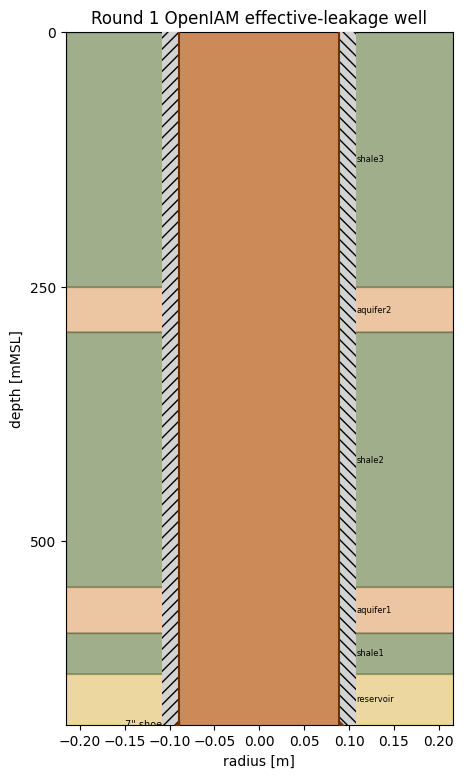

In [7]:
import matplotlib.pyplot as plt

fig, ax = processed_well.plot_sketch(
    draw_geology=True,
    draw_annotation=True,
    draw_open_hole=False,
)
fig.set_size_inches(5, 9)
ax.set_title("Round 1 OpenIAM effective-leakage well")

sketch_path = round1_root / "round1_openiam_effective_leakage_well.png"
fig.savefig(sketch_path, dpi=200, bbox_inches="tight")
sketch_path.relative_to(repo_root)

## SCREEN and OpenIAM Bridge

These fields are the first-round bridge between the two tools. The comparison should start with effective leakage rates and cumulative leaked mass, not detailed plug performance.

In [8]:
bridge = pd.DataFrame(
    [
        ["stratigraphy", "Stratigraphy shale/aquifer thicknesses", "WellClass stratigraphy intervals"],
        ["leakage permeability", "msw1.Parameters.logWellPerm [log10 m2]", "hole_casings[*].hc_perm [mD] for effective annulus"],
        ["reservoir pressure", "reservoirInitialPressure [Pa]", "SubsurfaceAssumptions p_resrv or p_fluid_contact [bar]"],
        ["run duration", "ModelParams.EndTime [years]", "simulation-years"],
        ["outputs", "CO2_aquifer#, mass_CO2_aquifer#", "CO2 leakage rate and cumulative mass from simulator outputs"],
    ],
    columns=["concept", "OpenIAM ex2c", "SCREEN/WellClass side"],
)
bridge

,concept,OpenIAM ex2c,SCREEN/WellClass side
0,stratigraphy,Stratigraphy shale/aquifer thicknesses,WellClass stratigraphy intervals
1,leakage permeability,msw1.Parameters.logWellPerm [log10 m2],hole_casings[*].hc_perm [mD] for effective ann...
2,reservoir pressure,reservoirInitialPressure [Pa],SubsurfaceAssumptions p_resrv or p_fluid_conta...
3,run duration,ModelParams.EndTime [years],simulation-years
4,outputs,"CO2_aquifer#, mass_CO2_aquifer#",CO2 leakage rate and cumulative mass from simu...


## Locate Existing OpenIAM Results

If ex2c has already been run, the newest output folder is summarized here. These CSVs are the OpenIAM side of the round 1 comparison.

In [9]:
output_root = openiam_root / "output"
output_dirs = sorted(output_root.glob("output_ex2c_*"), key=lambda path: path.stat().st_mtime)
latest_openiam_output = output_dirs[-1] if output_dirs else None

if latest_openiam_output is None:
    print("No OpenIAM ex2c output directories found.")
else:
    print(latest_openiam_output.relative_to(repo_root))
    result_files = [
        "AnalyticalReservoir1_000.pressure.csv",
        "AnalyticalReservoir1_000.CO2saturation.csv",
        "msw1_000.CO2_aquifer1.csv",
        "msw1_000.CO2_aquifer2.csv",
        "msw1AdapterAll_000.mass_CO2_aquifer1.csv",
        "msw1AdapterAll_000.mass_CO2_aquifer2.csv",
    ]
    display(pd.DataFrame({"result_csv": [str((latest_openiam_output / "csv_files" / name).relative_to(repo_root)) for name in result_files]}))

work/benchmark/repos/OpenIAM/output/output_ex2c_2026-09-14_09.09.57


,result_csv
0,work/benchmark/repos/OpenIAM/output/output_ex2...
1,work/benchmark/repos/OpenIAM/output/output_ex2...
2,work/benchmark/repos/OpenIAM/output/output_ex2...
3,work/benchmark/repos/OpenIAM/output/output_ex2...
4,work/benchmark/repos/OpenIAM/output/output_ex2...
5,work/benchmark/repos/OpenIAM/output/output_ex2...


In [10]:
if latest_openiam_output is not None:
    final_rows = []
    for csv_name in [
        "AnalyticalReservoir1_000.pressure.csv",
        "AnalyticalReservoir1_000.CO2saturation.csv",
        "msw1_000.CO2_aquifer1.csv",
        "msw1_000.CO2_aquifer2.csv",
        "msw1AdapterAll_000.mass_CO2_aquifer1.csv",
        "msw1AdapterAll_000.mass_CO2_aquifer2.csv",
    ]:
        csv_path = latest_openiam_output / "csv_files" / csv_name
        if csv_path.exists():
            frame = pd.read_csv(csv_path)
            final_row = frame.tail(1).copy()
            final_row.insert(0, "source", csv_name)
            final_rows.append(final_row)

    if final_rows:
        display(pd.concat(final_rows, ignore_index=True))

,source,Time (days),AnalyticalReservoir1_000.pressure,AnalyticalReservoir1_000.CO2saturation,msw1_000.CO2_aquifer1,msw1_000.CO2_aquifer2,msw1AdapterAll_000.mass_CO2_aquifer1,msw1AdapterAll_000.mass_CO2_aquifer2
0,AnalyticalReservoir1_000.pressure.csv,3652.5,6310015.35,NaN,NaN,NaN,NaN,NaN
1,AnalyticalReservoir1_000.CO2saturation.csv,3652.5,NaN,0.9,NaN,NaN,NaN,NaN
2,msw1_000.CO2_aquifer1.csv,3652.5,NaN,NaN,0.000026,NaN,NaN,NaN
3,msw1_000.CO2_aquifer2.csv,3652.5,NaN,NaN,NaN,0.000018,NaN,NaN
4,msw1AdapterAll_000.mass_CO2_aquifer1.csv,3652.5,NaN,NaN,NaN,NaN,10233.682631,NaN
5,msw1AdapterAll_000.mass_CO2_aquifer2.csv,3652.5,NaN,NaN,NaN,NaN,NaN,1732.826527


## Round 1 Interpretation

This is a no-plug effective-leakage benchmark. A later round can introduce cement plugs on the SCREEN side and collapse them into lower-permeability OpenIAM segments or SALSA plugged/unplugged shale statuses.